# Online Payment Fraud Detection using Machine Learning in Python

##  <center> Importing Libraries and Datasets</center>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
data = pd.read_csv('Dataset.csv')
data.head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0


In [3]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6362620 entries, 0 to 6362619
Data columns (total 10 columns):
 #   Column          Dtype  
---  ------          -----  
 0   step            int64  
 1   type            object 
 2   amount          float64
 3   nameOrig        object 
 4   oldbalanceOrg   float64
 5   newbalanceOrig  float64
 6   nameDest        object 
 7   oldbalanceDest  float64
 8   newbalanceDest  float64
 9   isFraud         int64  
dtypes: float64(5), int64(2), object(3)
memory usage: 485.4+ MB


In [4]:
data.describe()

,step,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud
count,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06
mean,2.433972e+02,1.798619e+05,8.338831e+05,8.551137e+05,1.100702e+06,1.224996e+06,1.290820e-03
std,1.423320e+02,6.038582e+05,2.888243e+06,2.924049e+06,3.399180e+06,3.674129e+06,3.590480e-02
min,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,1.560000e+02,1.338957e+04,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
50%,2.390000e+02,7.487194e+04,1.420800e+04,0.000000e+00,1.327057e+05,2.146614e+05,0.000000e+00
75%,3.350000e+02,2.087215e+05,1.073152e+05,1.442584e+05,9.430367e+05,1.111909e+06,0.000000e+00
max,7.430000e+02,9.244552e+07,5.958504e+07,4.958504e+07,3.560159e+08,3.561793e+08,1.000000e+00


In [5]:
data.isnull().sum()

step              0
type              0
amount            0
nameOrig          0
oldbalanceOrg     0
newbalanceOrig    0
nameDest          0
oldbalanceDest    0
newbalanceDest    0
isFraud           0
dtype: int64

In [6]:
data.duplicated().sum()

np.int64(0)

# Data Visualization

In [7]:
obj = (data.dtypes == 'object')
object_cols = list(obj[obj].index)
objlist = data.columns[data.dtypes == 'object']
print("Categorical variables:", len(object_cols), "\nList of Categorical Object :", objlist)


int_ = (data.dtypes == 'int')
num_cols = list(int_[int_].index)
numlist = data.columns[data.dtypes == 'int']
print("\nInteger variables:", len(num_cols), "\nList of Int variables:",numlist)

fl = (data.dtypes == 'float')
fl_cols = list(fl[fl].index)
fllist = data.columns[data.dtypes == 'int']
print("\nFloat variables:", len(fl_cols),"\nList of float variables :" ,fllist)


Categorical variables: 3 
List of Categorical Object : Index(['type', 'nameOrig', 'nameDest'], dtype='object')

Integer variables: 2 
List of Int variables: Index(['step', 'isFraud'], dtype='object')

Float variables: 5 
List of float variables : Index(['step', 'isFraud'], dtype='object')


# Visualizing the Payment Type column using Seaborn

<Axes: xlabel='type', ylabel='count'>

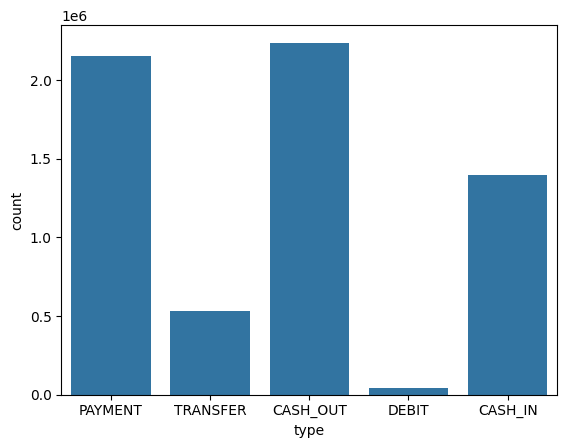

In [8]:
sns.countplot(x='type', data=data)

# Distribution of data across both predicted values.

In [9]:
data['isFraud'].value_counts()

isFraud
0    6354407
1       8213
Name: count, dtype: int64

# Visualizing the distribution of the 'step' column using a displot.

<Figure size 1500x600 with 0 Axes>

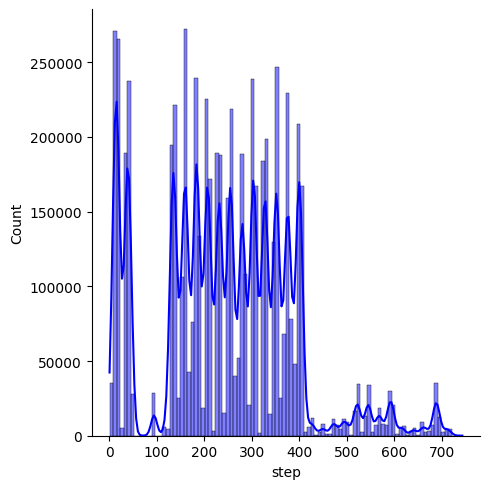

In [10]:
plt.figure(figsize=(15, 6))
sns.displot(data['step'], bins=100, kde=True, color='blue', alpha=0.5)

The maximum distribution among 100 to 400 of step

# Find the correlation among different features using Heatmap.

<Axes: >

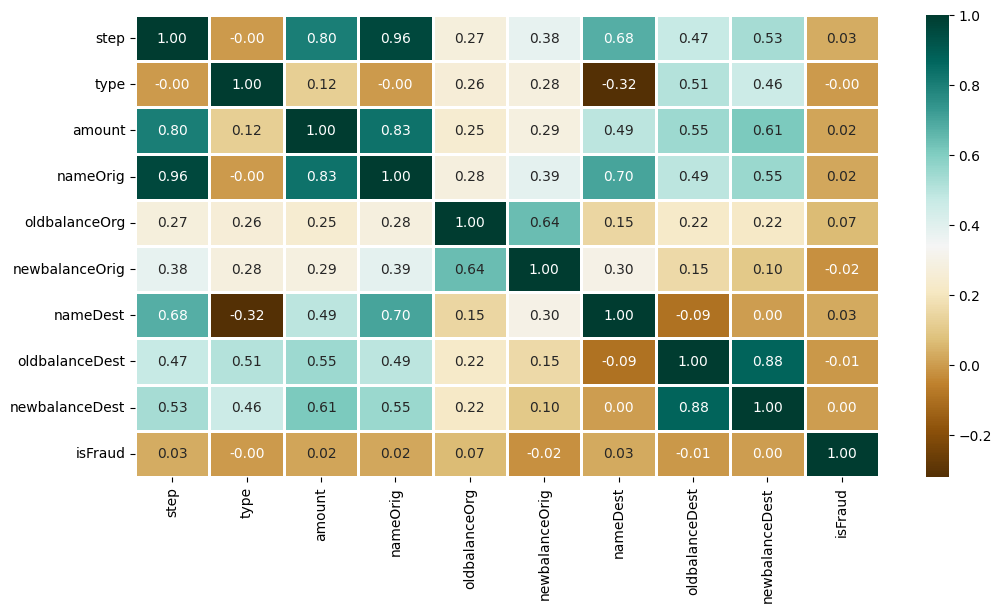

In [11]:
plt.figure(figsize=(12, 6))
sns.heatmap(data.apply(lambda x: pd.factorize(x)[0]).corr(),
            cmap='BrBG',
            fmt='.2f',
            linewidths=2,
            annot=True)

# <center> <u> Data Preprocessing </u></center>
This stage involves the following steps:

- Encoding the 'Type' column to convert categorical values into numerical format.
- Removing irrelevant columns such as nameOrig and nameDest to eliminate unnecessary data.
- Splitting the dataset into training and testing sets for model evaluation.

In [12]:
type_new = pd.get_dummies(data['type'], drop_first=True)
data_new = pd.concat([data, type_new], axis=1)
data_new.head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,CASH_OUT,DEBIT,PAYMENT,TRANSFER
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,False,False,True,False
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,False,False,True,False
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,False,False,False,True
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,True,False,False,False
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,False,False,True,False


# After completing the encoding process, we can now remove the irrelevant columns.

In [13]:
X = data_new.drop(['isFraud', 'type', 'nameOrig', 'nameDest'], axis=1)
y = data_new['isFraud']


In [14]:
X.head()

,step,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,CASH_OUT,DEBIT,PAYMENT,TRANSFER
0,1,9839.64,170136.0,160296.36,0.0,0.0,False,False,True,False
1,1,1864.28,21249.0,19384.72,0.0,0.0,False,False,True,False
2,1,181.00,181.0,0.00,0.0,0.0,False,False,False,True
3,1,181.00,181.0,0.00,21182.0,0.0,True,False,False,False
4,1,11668.14,41554.0,29885.86,0.0,0.0,False,False,True,False


# <center> Shape of extracted data </center>

In [15]:
X.shape, y.shape

((6362620, 10), (6362620,))

# <center> <u> Split the dataset into two parts: Training and Testing.</u></center>

In [16]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split( X, y, test_size=0.3, random_state=42)


# <center> Model Training </center>
Since the prediction task is a classification problem, the following machine learning models will be utilized:

- Logistic Regression: Predicts the probability that a given data point belongs to a specific category.
- XGBoost Classifier: Implements gradient-boosted decision trees, where trees are built sequentially, assigning weights to independent variables. These weighted variables are then used in decision trees to enhance predictive performance.
- Support Vector Classifier (SVC): Identifies an optimal hyperplane in an N-dimensional space to effectively separate data points into distinct categories, making predictions based on the closest support vectors.
- Random Forest Classifier: Constructs multiple decision trees from randomly selected subsets of the training data and aggregates their predictions through a voting mechanism to improve accuracy and reduce overfitting.

## Import the modules of the relevant models - 
### Logistic Regression,XGBoost Classifier, Support Vector Classifier (SVC), Random Forest Classifier

In [17]:
from xgboost import XGBClassifier
from sklearn.metrics import roc_auc_score as ras
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
import warnings


# Train the model

In [18]:
warnings.filterwarnings("ignore")

models = [LogisticRegression(), XGBClassifier(), RandomForestClassifier(n_estimators=7, criterion='entropy',random_state=7)]

for i in range(len(models)):
    models[i].fit(X_train, y_train)
    print(f'{models[i]} : ')
    
    train_preds = models[i].predict_proba(X_train)[:, 1]
    print('Training Accuracy : ', ras(y_train, train_preds))
    
    y_preds = models[i].predict_proba(X_test)[:, 1]
    print('Validation Accuracy : ', ras(y_test, y_preds))
    print()


LogisticRegression() : 
Training Accuracy :  0.8894134344500194
Validation Accuracy :  0.8870736435815861

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              gamma=None, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None,
              num_parallel_tree=None, random_state=None, ...) : 
Training Accuracy :  0.9999774189140321
Validation Accuracy :  0.999212631773824

RandomForestClassifier(criterion='entropy', n_esti

# Model Evaluation

The best-performed model is XGBClassifier. Let’s plot the Confusion Matrix for the same.

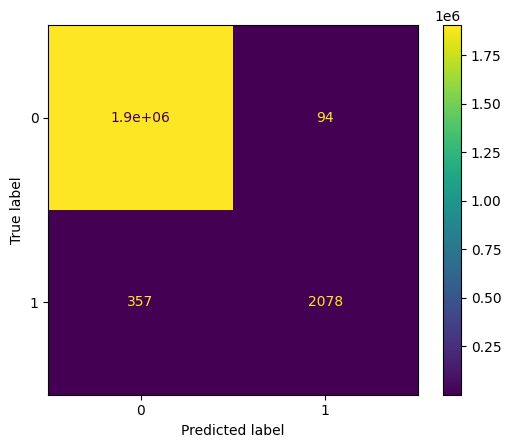

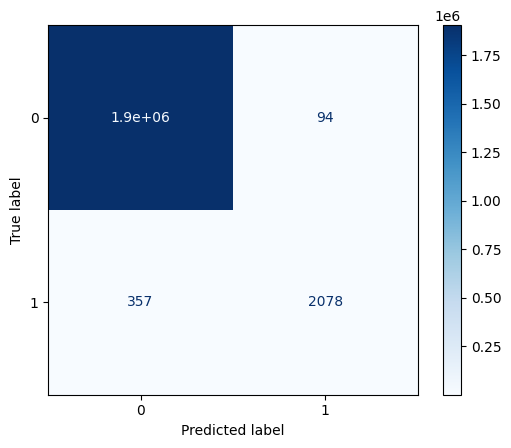

In [19]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = ConfusionMatrixDisplay.from_estimator(models[1], X_test, y_test) 

cm.plot(cmap='Blues') 

plt.show()


In [20]:
git init

SyntaxError: invalid syntax (2830201818.py, line 1)